In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
print(os.cpu_count())

144


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
import random as rand
import math

from qulacs import QuantumState,QuantumCircuit, Observable, PauliOperator,ParametricQuantumCircuit,DensityMatrix, GeneralQuantumOperator
from qulacs.gate import H,X,Y,Z,RX,RY,RZ,CNOT,CZ,TOFFOLI,SWAP,merge,DenseMatrix,add, Probabilistic, P0, P1,to_matrix_gate,PauliRotation,Pauli, RandomUnitary
from qulacs.state import inner_product, partial_trace, tensor_product

# Quantum circuits

In [3]:
# number of qubits
nqubits = 4

# observable
obs = GeneralQuantumOperator(nqubits)
obs.add_operator( PauliOperator("X 0 X 1", 1.0) )

In [4]:
# Generator lists for three types of circuits

## symmetric ansatz
generator_list_sc = ["XXII", "IIYY", 
                  "IZZI", "XIIX", 
                  "YYII", "IIZZ", 
                  "IXXI", "YIIY", 
                  "ZZII", "IIXX", 
                  "IYYI", "ZIIZ"]

## non-symmetric ansatz
generator_list_nsc = ["XIII", "IXII",
                  "IIXI", "IIIX", 
                  "YIII", "IYII",
                  "IIYI", "IIIY", 
                  "ZZII", "IZZI",
                  "IIZZ", "ZIIZ"]

## SLPA
generator_list_cbc = ["XXII", "IIXX", "YYZZ", "ZZYY", 
                  "IIYY", "YYII", "XXZZ", "ZZXX",
                  "IZZI", "ZIIZ", "XYYX", "YXXY",
                  "XIIX", "IXXI", "ZYYZ", "YZZY",
                  "YYII", "IIYY", "XXZZ", "ZZXX",
                  "IIZZ", "ZZII", "XXYY", "YYXX",
                  "XIIX", "IXXI", "ZYYZ", "YZZY",
                  "YIIY", "IYYI", "XZZX", "ZXXZ",
                  "IIZZ", "ZZII", "XXYY", "YYXX",
                  "XXII", "IIXX", "YYZZ", "ZZYY", 
                  "YIIY", "IYYI", "XZZX", "ZXXZ",
                  "IZZI", "ZIIZ", "XYYX", "YXXY",
                 ]

In [5]:
def random_initialize(params):
    for i in range(len(params)):
        params[i] = 2 * np.pi * rand.random()

In [6]:
# convert string to the format of qulacs
def convert(string):
    target = []
    pauli = []
    for j,s in enumerate(string):
        if s=="X":
            target.append(j)
            pauli.append(1)
        elif s=="Y":
            target.append(j)
            pauli.append(2)
        elif s=="Z":
            target.append(j)
            pauli.append(3)
            
    return target, pauli


# convert string to the format of qulacs
def convert_obs(string):
    ss = ""
    for j,s in enumerate(string):
        if s=="X":
            ss += f"X {j} "
        elif s=="Y":
            ss += f"Y {j} "
        elif s=="Z":
            ss += f"Z {j} "
            
    return ss

# Calculate commutators

In [7]:
# Heisenberg picture of obs
def cal_Heisenberg(obs,d,params,target_pauli_list):
    
    for i in range(d):
        index = d-i-1
        target = target_pauli_list[index][0]
        pauli = target_pauli_list[index][1]
        gate = PauliRotation(target, pauli, -params[index])
        gate.update_quantum_state(obs)
        
    mat = obs.get_matrix()
    return mat

In [8]:
def cal_norm(A):
    B= A@np.conjugate(A)
    norm = np.trace(B)
    return norm

In [9]:
def commuting_plot(num_params, generator_list):
    params = np.zeros(num_params)
    random_initialize(params)
    
    ############################################################# List for targets and paulis of rotation gates
    target_pauli_list = []
    for i in range(num_params):
        s = i%len(generator_list)
        target,pauli = convert(generator_list[s])
        target_pauli_list.append([target,pauli])

    ############################################################# List for generators
    P_list = []
    for i in range(num_params):
        s = i%len(generator_list)
        gs = convert_obs(generator_list[s])

        gen = GeneralQuantumOperator(nqubits)
        gen.add_operator( PauliOperator(gs, 1.0) )

        mat_csr = gen.get_matrix()
        mat = mat_csr.toarray()
        P_list.append(mat)
        
    ############################################################# Heisenberg picture of observable
    # matrix representation of observable
    obs_csr = obs.get_matrix()
    obs_mat = obs_csr.toarray()

    # Encode observable into density matrix (just for technical reason)
    dm = DensityMatrix(nqubits)
    dm.load(obs_mat)

    # Heisenberg time evolution
    obs_H = cal_Heisenberg(dm,len(params),params,target_pauli_list)
    #print(obs_H)
    
    ############################################################# Heisenberg picture of generator
    gen_H_list = []

    for i in range(num_params):
        gen = P_list[i]
        dm = DensityMatrix(nqubits)
        dm.load(gen)
        gen_H = cal_Heisenberg(dm,i,params,target_pauli_list)

        gen_H_list.append(gen_H)
        
        
    ############################################################# gradient operator
    G_list = []
    for i in range(num_params):
        gen_H = gen_H_list[i]
        G = -1j * (gen_H@obs_H - obs_H@gen_H)
        G_list.append(G)
        
    ############################################################# Check whether gradient operators are commutative
    comm_list = np.zeros((num_params,num_params))
    for j in range(num_params):
        for k in range(num_params):
            G1 = G_list[j]
            G2 = G_list[k]
            comm = G1@G2 - G2@G1
            norm = cal_norm(comm)
            comm_list[j][k] = np.abs(norm)
            
    comm_list_01 = np.zeros((num_params,num_params))
    for j in range(num_params):
        for k in range(num_params):
            if comm_list[j][k] > 1e-12:
                comm_list_01[j][k] = 1 #non-commutative
            else:
                comm_list_01[j][k] = 0 #commutative
    
    return comm_list_01

# Calculate the minimum number of simultaneously measurable groups

In [10]:
# Find the maximum clique, and then remove it
def find_and_remove_clique(comm_list_01):
    size = len(comm_list_01[0])
    
    # Map the commutation relations of gradiet operators to a graph
    G = [set() for i in range(size)]
    for i in range(size):
        edge = []
        for j in range(size):
            if comm_list_01[i][j] == 0 and i!=j:
                edge.append(j) # Nodes are connected by an edge if they are commutative
        G[i] |= set(edge)        
        
    # Find the maximum clique
    clique = list( maximum_clique(size,G) )
    clique.sort()
    #print(clique)
    
    # Remove the maximum clique
    for i in range(len(clique)):
        index = len(clique) - i - 1
        a = clique[index]
        comm_list_01 = np.delete(comm_list_01, a, 0)
        comm_list_01 = np.delete(comm_list_01, a, 1)
    
    return comm_list_01

In [11]:
# Iteratively find and remove maximum cliques, and calculate the minimum number of groupings
def cal_number_of_group(comm_list_01):
    size = len(comm_list_01[0])
    counter = 0
    
    while size >= 1:
        comm_list_01 = find_and_remove_clique(comm_list_01)
        #print(comm_list_01)
        size = len(comm_list_01)
        counter += 1
        
    return counter

In [12]:
# Code for finding the maximum clique
def maximum_clique(N, G):
    def my_dfs(V, P, X):
        if not P and not X:
            # V is the maximum clique
            return V
        u = next(iter(X or P)) # a pivot vertex
        r = set()
        for v in P - G[u]:
            r0 = my_dfs(V | {v}, P & G[v], X & G[v])
            if len(r) < len(r0):
                r = r0
            P.remove(v)
            X.add(v)
        return r

    # degeneracy ordering for sorting vertices
    *I, = range(N)
    I.sort(key = lambda x: len(G[x]), reverse=1)

    ans = set()
    P = set(range(N))
    X = set()
    for v in I:
        res = my_dfs({v}, P & G[v], X & G[v])
        if len(ans) < len(res):
            ans = res
        P.remove(v)
        X.add(v)
    return ans

# example
# G[i] represents all vertices that are connected to ith vertex
G = [set() for i in range(6)]
G[0] |= {1, 2, 3, 4}
G[1] |= {0, 2, 5}
G[2] |= {0, 1, 3, 4}
G[3] |= {0, 2, 4}
G[4] |= {0, 2, 3}
G[5] |= {1}
x = list(maximum_clique(6, G))
print(G)
print(x)
print(maximum_clique(6, G))

[{1, 2, 3, 4}, {0, 2, 5}, {0, 1, 3, 4}, {0, 2, 4}, {0, 2, 3}, {1}]
[0, 2, 3, 4]
{0, 2, 3, 4}


# Two-dimensional plots

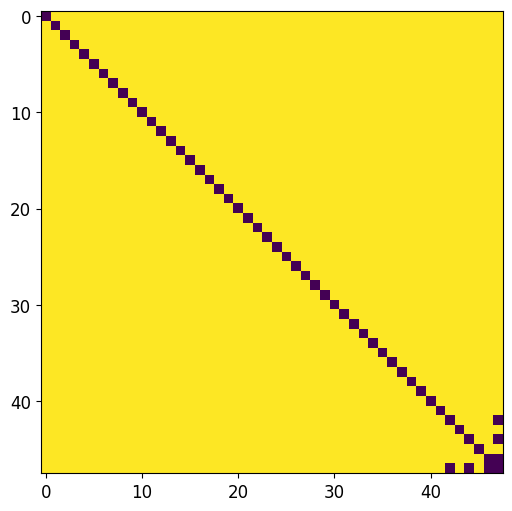

In [13]:
graph = commuting_plot(48, generator_list_sc)

fig = plt.figure(figsize=(6, 6))
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.imshow(graph)
plt.savefig("cmap_sc_4q.pdf", bbox_inches='tight', pad_inches=0.05)
plt.show()

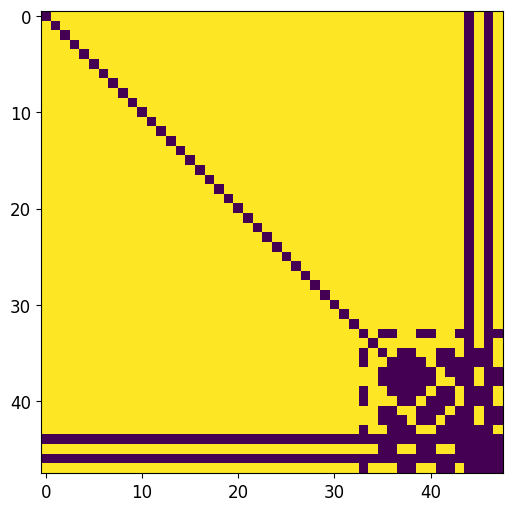

In [14]:
graph = commuting_plot(48, generator_list_nsc)

fig = plt.figure(figsize=(6, 6))
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.imshow(graph)
plt.savefig("cmap_nsc_4q.pdf", bbox_inches='tight', pad_inches=0.05)
plt.show()

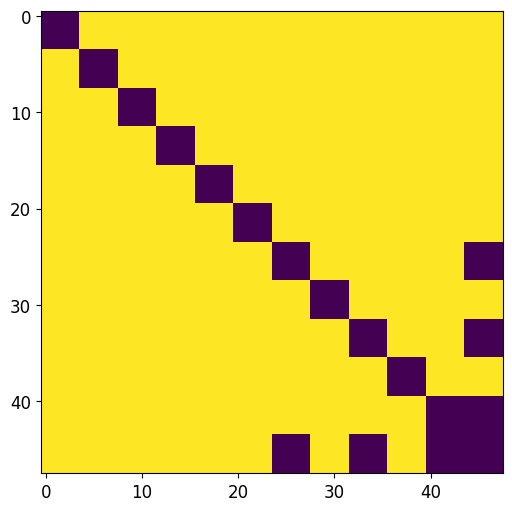

In [15]:
graph = commuting_plot(48, generator_list_cbc)

fig = plt.figure(figsize=(6, 6))
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.imshow(graph)
plt.savefig("cmap_cbc_4q.pdf", bbox_inches='tight', pad_inches=0.05)
plt.show()

# Gradient measurement efficiency

## Symmetric ansatz

In [16]:
xlist_sc = []

xlist_sc.append(3)

i=11
for _ in range(16):
    xlist_sc.append(i)
    i+=24
    
np.array(xlist_sc)

array([  3,  11,  35,  59,  83, 107, 131, 155, 179, 203, 227, 251, 275,
       299, 323, 347, 371])

In [17]:
%%time
ylist_sc = []
for x in xlist_sc:
    comm = commuting_plot(x, generator_list_sc)
    y = cal_number_of_group(comm)
    ylist_sc.append( y )
    
ylist_sc = np.array(ylist_sc)
zlist_sc = xlist_sc/ylist_sc

CPU times: user 30.8 s, sys: 80 ms, total: 30.9 s
Wall time: 30.9 s


## Non-symmetric ansatz

In [18]:
xlist_nsc = []

xlist_nsc.append(3)

i=11
for _ in range(16):
    xlist_nsc.append(i)
    i+=24
    
np.array(xlist_nsc)

array([  3,  11,  35,  59,  83, 107, 131, 155, 179, 203, 227, 251, 275,
       299, 323, 347, 371])

In [19]:
%%time
ylist_nsc = []
for x in xlist_nsc:
    comm = commuting_plot(x, generator_list_nsc)
    y = cal_number_of_group(comm)
    ylist_nsc.append( y )
    
ylist_nsc = np.array(ylist_nsc)
zlist_nsc = xlist_nsc/ylist_nsc

CPU times: user 29.1 s, sys: 120 ms, total: 29.3 s
Wall time: 29.3 s


## SLPA

In [20]:
xlist_cbc = []
i=3
for _ in range(8):
    xlist_cbc.append(4*i)
    i+=8
    xlist_cbc.append(4*i)
    i+=4
    
np.array(xlist_cbc)

array([ 12,  44,  60,  92, 108, 140, 156, 188, 204, 236, 252, 284, 300,
       332, 348, 380])

In [21]:
%%time
ylist_cbc = []
for x in xlist_cbc:
    comm = commuting_plot(x, generator_list_cbc)
    y = cal_number_of_group(comm)
    ylist_cbc.append( y )
    
ylist_cbc = np.array(ylist_cbc)
zlist_cbc = xlist_cbc/ylist_cbc

CPU times: user 23.9 s, sys: 128 ms, total: 24.1 s
Wall time: 24 s


## Plots

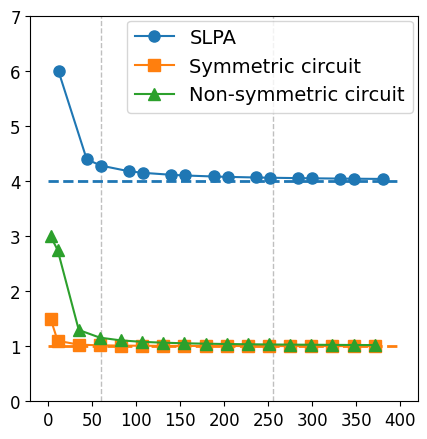

In [22]:
fig = plt.figure(figsize=(5,5))
plt.ylim(0,7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.vlines(60, 0, 7, linestyle='dashed', color="gray", linewidth=1, alpha=0.5)
plt.vlines(255, 0, 7, linestyle='dashed', color="gray", linewidth=1, alpha=0.5)
plt.hlines(4, -0, 400, linestyle='dashed', color='tab:blue', linewidth=2)
plt.hlines(1, -0, 400, linestyle='dashed', color='tab:orange', linewidth=2)

plt.plot(xlist_cbc,zlist_cbc,marker='o', markersize=8, label='SLPA')
plt.plot(xlist_sc,zlist_sc,marker='s', markersize=8, label='Symmetric circuit')
plt.plot(xlist_nsc,zlist_nsc,marker='^', markersize=8, label='Non-symmetric circuit')
#plt.grid()


plt.legend(fontsize=14, loc=(0.25,0.75))
plt.savefig("efficiency_4q.pdf", bbox_inches='tight', pad_inches=0.05)
plt.show()